# Exercise P3: Noise Type Detector & Filter

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

image_path = "input_images/bai3/image.png"
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print(f"Không tìm thấy ảnh: {image_path}")

In [20]:
if 'img' in locals() and img is not None:
    outlier_ratio = np.sum((img <= 2) | (img >= 253)) / img.size
    
    if outlier_ratio > 0.03:
        noise_type = "Salt-and-Pepper"
        filtered_img = cv2.medianBlur(img, 5)
        filter_name = "Median Filter"
    else:
        noise_type = "Gaussian / Other"
        filtered_img = cv2.bilateralFilter(img, 9, 75, 75)
        filter_name = "Bilateral Filter"
    
    print(f"Phân tích: Phát hiện nhiễu {noise_type} -> Dùng: {filter_name}")

Phân tích: Phát hiện nhiễu Salt-and-Pepper -> Dùng: Median Filter


In [21]:
if 'filtered_img' in locals():
    output_dir = "output_images/bai3"
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    output_path = os.path.join(output_dir, "filtered_image.png")
    cv2.imwrite(output_path, filtered_img)

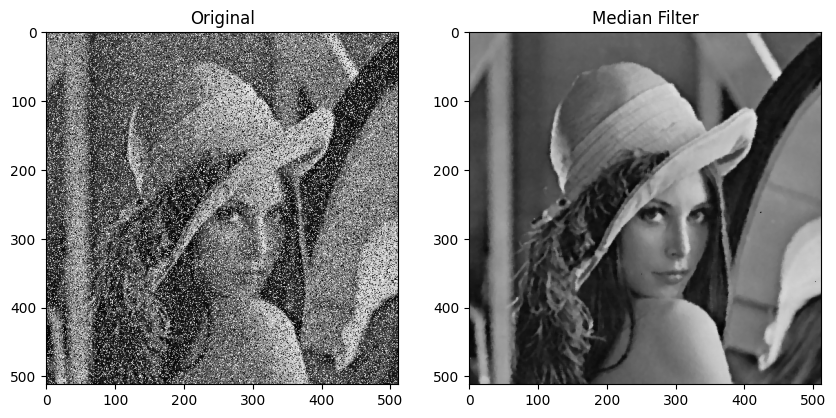

In [22]:
if 'filtered_img' in locals():
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title("Original")
    plt.subplot(1, 2, 2); plt.imshow(filtered_img, cmap='gray'); plt.title(filter_name)
    plt.show()